<a href="https://colab.research.google.com/github/amcmdv/Gemini-carnival/blob/main/21122025_Modeling_How_Metabolic_Stress_Affects_Neuronal_Firing_Patterns_and_Leads_To_%22Silencing%22_or_%22Excitotoxicity_%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This combines **metabolic biochemistry** with **graph theory**. Below is a complete Python implementation orginally created in Colab.

It has been designed to generate a template CSV if one isn't uploaded, so you can see the required "dimensions" (parameters) format.

### The Mathematical Model

We are modeling each neuron as a coupled system of two differential equations:

1. **Membrane Potential ():** Driven by external stimulus, synaptic input from neighbors, and an "instability" term that grows as ATP-dependent pumps fail.


2. **Metabolic State ():** Depleted by housekeeping, active pumping, and spiking events; replenished by a production rate (the "Oxygen/Glucose" variable).



---

### Colab Implementation

Step 1: Load Configuration
Created 'config.csv' template. Please download, edit, and re-upload if you want custom dimensions.


Saving config.csv to config (1).csv
No file uploaded, using defaults.
Step 2: Running simulation for 10 cells...
Step 3: Generating Visual Report and Node Graph...


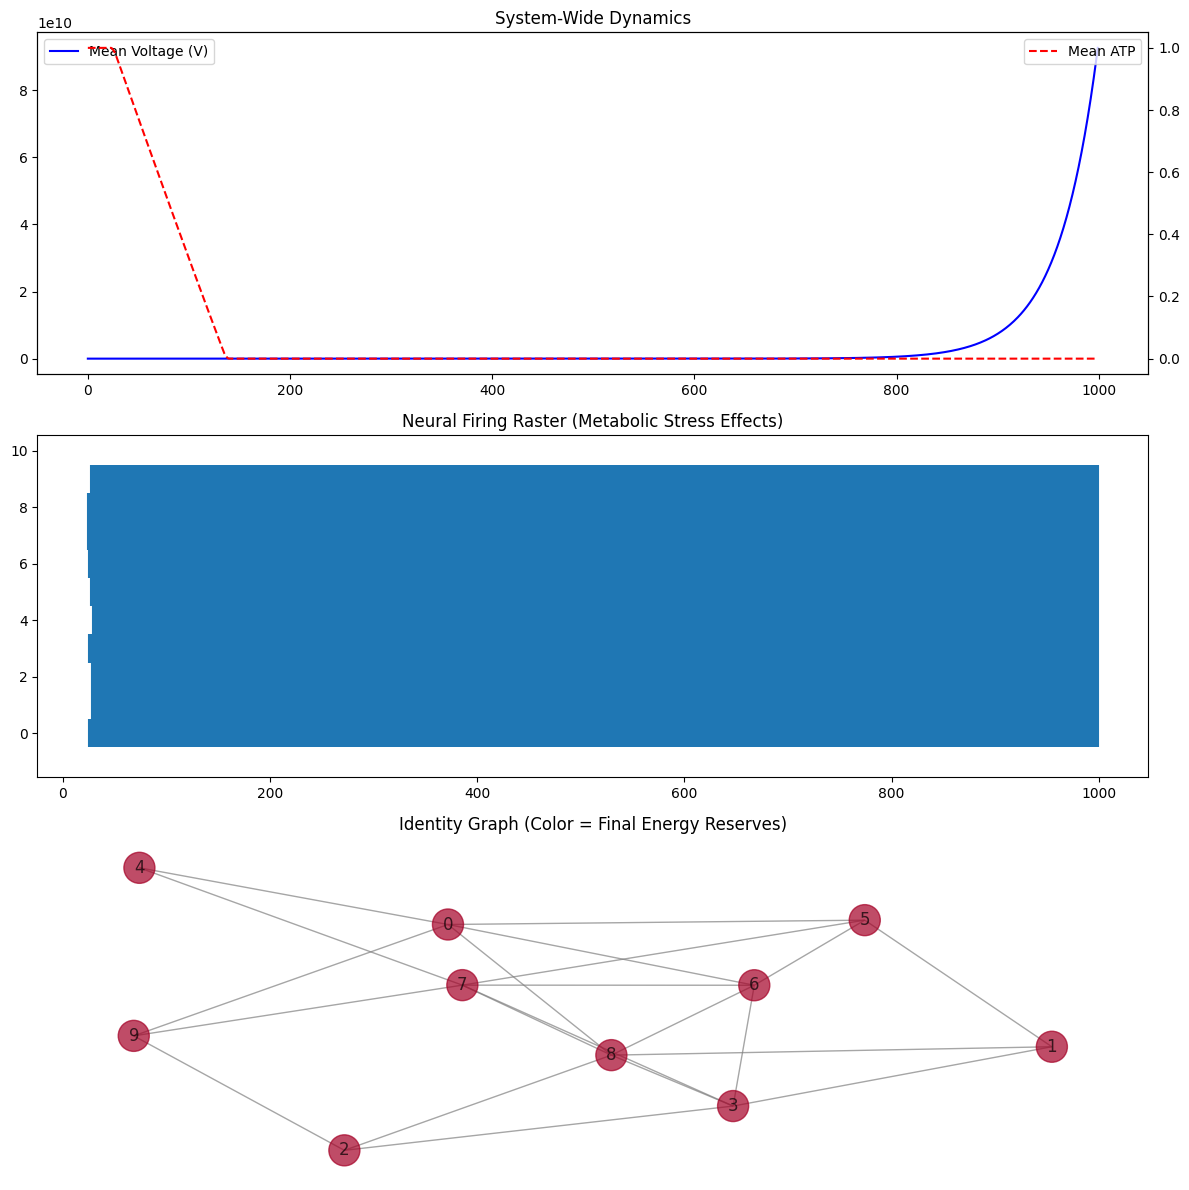

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, asdict
from typing import Dict, Any, List
from google.colab import files
import os

# 1. CORE DATA STRUCTURE
@dataclass
class SimConfig:
    n_cells: int = 10
    connectivity_prob: float = 0.3
    T: float = 100.0
    dt: float = 0.1
    atp_prod_base: float = 0.02  # This represents Glucose/O2 availability
    spike_threshold: float = 0.8
    coupling_strength: float = 0.1

# 2. SIMULATION ENGINE
class NeuroMetabolicSim:
    def __init__(self, config: SimConfig):
        self.c = config
        self.steps = int(self.c.T / self.c.dt)
        self.rng = np.random.default_rng()

        # Create Graph (The Graph)
        self.G = nx.erdos_renyi_graph(n=self.c.n_cells, p=self.c.connectivity_prob)
        self.adj = nx.to_numpy_array(self.G)

        # Initialise States
        self.v = np.zeros((self.c.n_cells, self.steps))
        self.atp = np.ones((self.c.n_cells, self.steps))
        self.spikes = np.zeros((self.c.n_cells, self.steps))

    def run(self):
        for k in range(1, self.steps):
            # Calculate Pump Efficiency (Sigmoid response to ATP)
            pump_eff = self.atp[:, k-1] / (self.atp[:, k-1] + 0.5)

            # Synaptic Input (Coupling from neighbors)
            synaptic_in = self.c.coupling_strength * np.dot(self.adj, self.v[:, k-1])

            # External Stimulus (Periodic)
            stim = 0.5 * np.sin(k * self.c.dt * 0.5)

            # Voltage Update
            dv = (
                0.5 * stim +
                synaptic_in +
                0.3 * (1.0 - pump_eff) - # Instability from metabolic failure
                0.2 * self.v[:, k-1] +
                0.05 * self.rng.normal(size=self.c.n_cells)
            ) * self.c.dt

            self.v[:, k] = self.v[:, k-1] + dv

            # Check for Spikes
            self.spikes[:, k] = (self.v[:, k] > self.c.spike_threshold).astype(float)

            # ATP Update
            atp_gain = self.c.atp_prod_base * self.c.dt
            atp_loss = (0.005 + 0.01 * pump_eff + 0.1 * self.spikes[:, k]) * self.c.dt
            self.atp[:, k] = np.clip(self.atp[:, k-1] + atp_gain - atp_loss, 0, 1.0)

    def generate_report(self):
        fig, axes = plt.subplots(3, 1, figsize=(12, 12))

        # Plot 1: Mean Voltage and ATP
        axes[0].plot(np.mean(self.v, axis=0), label="Mean Voltage (V)", color='blue')
        axes[0].set_title("System-Wide Dynamics")
        ax2 = axes[0].twinx()
        ax2.plot(np.mean(self.atp, axis=0), label="Mean ATP", color='red', linestyle='--')
        axes[0].legend(loc='upper left'); ax2.legend(loc='upper right')

        # Plot 2: Raster Plot of Spikes
        axes[1].eventplot([np.where(self.spikes[i] > 0)[0] for i in range(self.c.n_cells)])
        axes[1].set_title("Neural Firing Raster (Metabolic Stress Effects)")

        # Plot 3: Node Graph (Connectivity Colored by Final ATP)
        pos = nx.spring_layout(self.G)
        final_atp = self.atp[:, -1]
        nx.draw(self.G, pos, ax=axes[2], node_color=final_atp, cmap='RdYlGn',
                with_labels=True, node_size=500, edge_color='gray', alpha=0.7)
        axes[2].set_title("Node Graph (Color = Final Energy Reserves)")

        plt.tight_layout()
        plt.show()

# 3. INTERFACE LOGIC
def start_pipeline():
    print("Step 1: Load Configuration")
    if not os.path.exists('config.csv'):
        # Generate template if not present
        template = pd.DataFrame([asdict(SimConfig())])
        template.to_csv('config.csv', index=False)
        print("Created 'config.csv' template. Please download, edit, and re-upload if you want custom dimensions.")

    # In Colab, we prompt for upload
    uploaded = files.upload()
    if 'config.csv' in uploaded:
        df = pd.read_csv('config.csv')
        params = df.iloc[0].to_dict()
        # Clean numeric types
        params['n_cells'] = int(params['n_cells'])
        config = SimConfig(**params)
    else:
        print("No file uploaded, using defaults.")
        config = SimConfig()

    print(f"Step 2: Running simulation for {config.n_cells} cells...")
    sim = NeuroMetabolicSim(config)
    sim.run()

    print("Step 3: Generating Visual Report and Node Graph...")
    sim.generate_report()

# Execute
start_pipeline()

---

### How to use this for your Specific Scenarios

#### Scenario A: Modeling Silencing (Low Glucose)

1. Set `atp_prod_base` to a very low value (e.g., `0.005`) in your spreadsheet.
2. **Result:** You will see the ATP graph drop quickly. The raster plot will show neurons firing initially, then going completely silent as they lack the energy to maintain the membrane potential.

#### Scenario B: Modeling Excitotoxicity (Moderate Stress)

1. Set `atp_prod_base` to a medium value (e.g., `0.012`) and increase `coupling_strength`.
2. **Result:** The "Pump Failure" term in the code `0.3 * (1.0 - pump_eff)` will cause the voltage to drift upward. Because the cells are connected in the **Node Graph**, one cell's instability will trigger its neighbours, leading to a "runaway" firing event where cells fire rapidly until they completely deplete their ATP.

### Explaining the Outputs

* **Node Graph:** This shows which neurons are "influencers" in the network. If a central node (high degree) runs out of ATP, it can destabilise the entire cluster. Nodes colored **Red** are metabolically exhausted (dead/silent), while **Green** nodes are healthy.
* **Raster Plot:** This captures the "Firing Pattern." In metabolic stress, you often see "bursting" followed by a permanent flatline.
